In [17]:
#Load Train/Test Data
import pandas as pd

train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")

In [18]:
#Build Interaction Matrix
import numpy as np

num_users = train_df['user_id_enc'].max() + 1
num_items = train_df['item_id_enc'].max() + 1

R = np.zeros((num_users, num_items))

R[
    train_df['user_id_enc'],
    train_df['item_id_enc']
] = train_df['interaction']

# Matrix Factorization using SVD

We approximate:

𝑅
≈
𝑈
⋅
𝑉
𝑇
R≈U⋅V
T

In [19]:
from scipy.sparse.linalg import svds

k = 50  # latent factors

U, sigma, Vt = svds(R, k=k)

sigma = np.diag(sigma)

R_pred = np.dot(np.dot(U, sigma), Vt)

In [20]:
#Generate Recommendations
#Function: Top-K items
def recommend(user_id, R_pred, k=10):
    scores = R_pred[user_id]
    
    top_items = np.argsort(scores)[::-1][:k]
    
    return top_items

In [21]:
recommend(0, R_pred, k=10)

array([227, 221,  88,  55, 172, 175,  11, 150, 126, 174])

In [22]:
#Improvement
def recommend(user_id, R_pred, train_df, k=10):
    seen_items = train_df[train_df['user_id_enc'] == user_id]['item_id_enc'].values
    
    scores = R_pred[user_id]
    
    scores[seen_items] = -np.inf
    
    top_items = np.argsort(scores)[::-1][:k]
    
    return top_items

# Evaluation Metrics

In [23]:
#Precision@K
def precision_at_k(actual, predicted, k=10):
    predicted = predicted[:k]
    return len(set(predicted) & set(actual)) / k

In [24]:
#Recall@K
def recall_at_k(actual, predicted, k=10):
    predicted = predicted[:k]
    return len(set(predicted) & set(actual)) / len(actual)

In [25]:
#NDCG@K
import numpy as np

def ndcg_at_k(actual, predicted, k=10):
    dcg = 0
    for i, p in enumerate(predicted[:k]):
        if p in actual:
            dcg += 1 / np.log2(i + 2)
    
    idcg = sum([1 / np.log2(i + 2) for i in range(min(len(actual), k))])
    
    return dcg / idcg if idcg > 0 else 0

In [26]:
#Evaluate Model
precisions = []
recalls = []
ndcgs = []

users = test_df['user_id_enc'].unique()

for user in users:
    actual = test_df[test_df['user_id_enc'] == user]['item_id_enc'].values
    
    if len(actual) == 0:
        continue
    
    predicted = recommend(user, R_pred, train_df, k=10)
    
    precisions.append(precision_at_k(actual, predicted))
    recalls.append(recall_at_k(actual, predicted))
    ndcgs.append(ndcg_at_k(actual, predicted))

In [27]:
#Final Metrics
print("Precision@10:", np.mean(precisions))
print("Recall@10:", np.mean(recalls))
print("NDCG@10:", np.mean(ndcgs))

Precision@10: 0.2528723404255319
Recall@10: 0.16610214755376745
NDCG@10: 0.30085248373262863


In [28]:
np.save("../data/processed/R_pred.npy", R_pred)

In [29]:
results = {
    "precision@10": float(np.mean(precisions)),
    "recall@10": float(np.mean(recalls)),
    "ndcg@10": float(np.mean(ndcgs))
}

import json

with open("../data/processed/results.json", "w") as f:
    json.dump(results, f)

# Model Optimization & Analysis

In [30]:
#Hyperparameter Tuning (SVD)
#Try Different k Values
from scipy.sparse.linalg import svds
import numpy as np

k_values = [20, 50, 100]

results = []

for k in k_values:
    U, sigma, Vt = svds(R, k=k)
    sigma = np.diag(sigma)
    
    R_pred = np.dot(np.dot(U, sigma), Vt)
    
    precisions, recalls, ndcgs = [], [], []
    
    for user in test_df['user_id_enc'].unique():
        actual = test_df[test_df['user_id_enc'] == user]['item_id_enc'].values
        
        if len(actual) == 0:
            continue
        
        predicted = recommend(user, R_pred, train_df, k=10)
        
        precisions.append(precision_at_k(actual, predicted))
        recalls.append(recall_at_k(actual, predicted))
        ndcgs.append(ndcg_at_k(actual, predicted))
    
    results.append({
        "k": k,
        "precision": np.mean(precisions),
        "recall": np.mean(recalls),
        "ndcg": np.mean(ndcgs)
    })


In [31]:
#Print Results
for r in results:
    print(r)

{'k': 20, 'precision': np.float64(0.30234042553191487), 'recall': np.float64(0.1932837926460391), 'ndcg': np.float64(0.3658532669726781)}
{'k': 50, 'precision': np.float64(0.2528723404255319), 'recall': np.float64(0.16610214755376745), 'ndcg': np.float64(0.30085248373262863)}
{'k': 100, 'precision': np.float64(0.1896808510638298), 'recall': np.float64(0.13216866042980996), 'ndcg': np.float64(0.22943488930245845)}


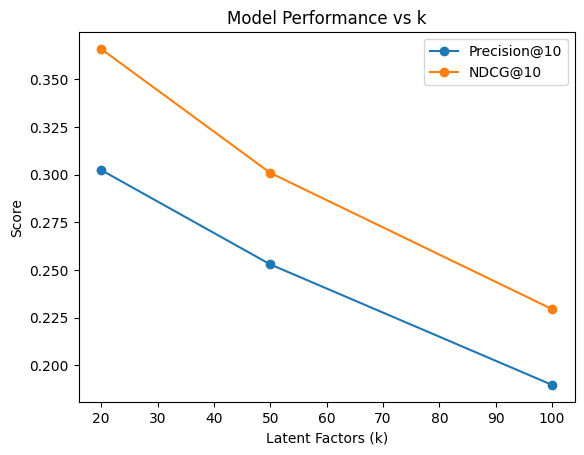

In [32]:
#Visualization 
import matplotlib.pyplot as plt

k_vals = [r['k'] for r in results]
precisions = [r['precision'] for r in results]
ndcgs = [r['ndcg'] for r in results]

plt.plot(k_vals, precisions, marker='o', label="Precision@10")
plt.plot(k_vals, ndcgs, marker='o', label="NDCG@10")

plt.xlabel("Latent Factors (k)")
plt.ylabel("Score")
plt.title("Model Performance vs k")
plt.legend()
plt.show()

# Model Comparison

In [33]:
#Baseline 1 — Popularity Model
popular_items = train_df.groupby('item_id_enc').size().sort_values(ascending=False).index.values

def recommend_popular(k=10):
    return popular_items[:k]

In [34]:
#Evaluate Popularity Model
precisions_pop = []

for user in test_df['user_id_enc'].unique():
    actual = test_df[test_df['user_id_enc'] == user]['item_id_enc'].values
    
    if len(actual) == 0:
        continue
    
    predicted = recommend_popular(10)
    
    precisions_pop.append(precision_at_k(actual, predicted))

print("Popularity Precision:", np.mean(precisions_pop))

Popularity Precision: 0.10606382978723404


In [36]:
df = pd.read_csv("../data/processed/ratings_final.csv")

In [37]:
#Threshold Experiment

df['interaction'] = (df['rating'] >= 3).astype(int)

In [38]:
(df['rating'] >= 4)

0        False
1        False
2        False
3        False
4        False
         ...  
99995    False
99996     True
99997    False
99998    False
99999    False
Name: rating, Length: 100000, dtype: bool

In [39]:
#Error Analysis (VERY IMPORTANT)
#Find Weak Users
user_scores = []

for user in test_df['user_id_enc'].unique():
    actual = test_df[test_df['user_id_enc'] == user]['item_id_enc'].values
    
    if len(actual) == 0:
        continue
    
    predicted = recommend(user, R_pred, train_df, k=10)
    
    score = precision_at_k(actual, predicted)
    
    user_scores.append((user, score))

# lowest performing users
sorted(user_scores, key=lambda x: x[1])[:10]

[(np.int64(814), 0.0),
 (np.int64(258), 0.0),
 (np.int64(836), 0.0),
 (np.int64(321), 0.0),
 (np.int64(851), 0.0),
 (np.int64(858), 0.0),
 (np.int64(164), 0.0),
 (np.int64(76), 0.0),
 (np.int64(515), 0.0),
 (np.int64(326), 0.0)]

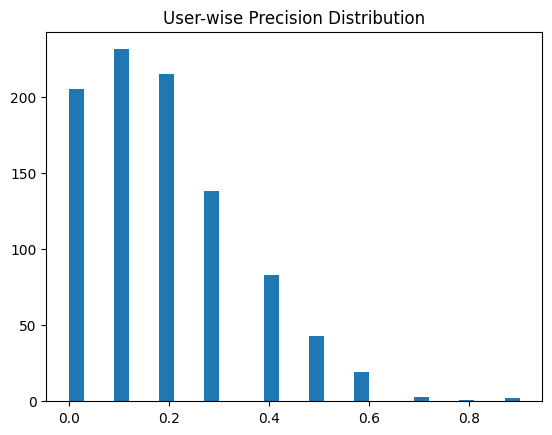

In [40]:
#Performance Distribution
scores = [s[1] for s in user_scores]

plt.hist(scores, bins=30)
plt.title("User-wise Precision Distribution")
plt.show()

In [41]:
#Save Experiment Results
import json

with open("../data/processed/experiment_results.json", "w") as f:
    json.dump(results, f)